# Strategic Audit of the PCV Program in Guatemala  
### Third Notebook: Interpretative Data Analysis

This notebook builds directly on the consolidated analytical dataset produced in the previous stage, which integrated heterogeneous program sources into a unified, project-centric structure. While the second notebook focused on structural validation and data preparation, this stage shifts the analytical focus toward interpretation, pattern discovery, and exploratory insight generation.

Given the reconstructed nature of the dataset, characterized by proxy-based indicators, composite indices, and rule-based classifications, the objective of this notebook is not statistical inference or predictive modeling, but the systematic exploration of internal patterns across the program architecture. Particular attention is given to understanding how project typologies, operational intensity, and multidimensional performance indicators interact across organizational levels.

Unlike the previous notebook, which prioritized structural consistency and data integrity, this stage aims to translate the reconstructed dataset into interpretable analytical narratives. The goal is to bridge the gap between data construction and modeling by generating the first layer of substantive insights that will inform subsequent analysis and final strategic synthesis.

**Author:** J-F Jutras  
**Date:** May 2026  
**Dataset:** SUCO PCV Program Data (Guatemala)

## 3.1-Data Loading

In [1]:
import pandas as pd
import sys
import warnings

# Suppress openpyxl warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# File path (Kaggle dataset)
file_path = "/kaggle/input/datasets/jfjutras07/pcv-guatemala-dataset-cleaned/pcv_guatemala_project_dataset.csv"

# Load dataset
df = pd.read_csv(file_path)

# Define path for PCV_Guatelmala_Dataset
PCV_path = "/kaggle/input/datasets/jfjutras07/pcv-guatemala-dataset/"

# Load all tables
df_capacidades = pd.read_excel(PCV_path + "Tabla_capacidades.xlsx")
df_componentes = pd.read_excel(PCV_path + "Tabla_componentes.xlsx")
df_cooperantes = pd.read_excel(PCV_path + "Tabla_cooperantes.xlsx")
df_entregables = pd.read_excel(PCV_path + "Tabla_entregables.xlsx")
df_mandatos = pd.read_excel(PCV_path + "Tabla_mandatos.xlsx")
df_proyectos = pd.read_excel(PCV_path + "Tabla_proyectos.xlsx")
df_socios = pd.read_excel(PCV_path + "Tabla_socios.xlsx")

# Standardize column names
df.columns = df.columns.str.lower()

df_mandatos.columns = df_mandatos.columns.str.lower()
df_cooperantes.columns = df_cooperantes.columns.str.lower()
df_socios.columns = df_socios.columns.str.lower()
df_proyectos.columns = df_proyectos.columns.str.lower()
df_entregables.columns = df_entregables.columns.str.lower()

# Load custom library from GitHub
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
sys.path.append("/kaggle/working/jfj-utils")

#Quick check
df.head()

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (188/188), done.
remote: Total 3527 (delta 231), reused 99 (delta 99), pack-reused 3240 (from 4)
Receiving objects: 100% (3527/3527), 1.18 MiB | 14.95 MiB/s, done.
Resolving deltas: 100% (2322/2322), done.


,id_proyecto,id_componente,titulo_proyecto,tipo_proyecto,complejidad_promedio,complejidad_total,clasificación,duración estimada en meses,calidad,sostenibilidad,...,i_transformation,i_resultados,i_contexto,i_riesgo,nb_entregables,id_capacitad,titulo_componente,familia_capacidades,production_density,project_type
0,1,3,Política de género (TPS),"Plan, estrategía o política",2.68,16.1,Proyecto complejo y exigente,5,4,3,...,3.5,3.0,2.5,4.5,6,1,Política y protocolos integrales de género (sa...,Derecho de las mujeres e igualdad entre las mu...,1.20,Proyecto de beneficiarios (servicios externos)
1,2,3,Política de género (AGIMS),"Plan, estrategía o política",2.73,16.4,Proyecto complejo y exigente,5,4,4,...,3.5,3.0,3.5,4.5,6,1,Política y protocolos integrales de género (sa...,Derecho de las mujeres e igualdad entre las mu...,1.20,Proyecto de beneficiarios (servicios externos)
2,3,5,Herramientas de seguridad y salvaguardia,Herramientas,2.53,10.1,Proyecto complejo y exigente,4,3,2,...,2.5,2.0,2.0,4.0,4,1,Caja de herramientas - género,Derecho de las mujeres e igualdad entre las mu...,1.00,Proyecto de desempeño (servicios internos)
3,4,6,Capacitación sobre la política de género,Capacitación y transferencia de conocimientos,2.10,2.1,Proyecto ligero,4,3,2,...,3.0,4.0,3.0,4.5,1,1,Fortalecimiento de conocimientos y competencia...,Derecho de las mujeres e igualdad entre las mu...,0.25,Proyecto de beneficiarios (servicios externos)
4,5,6,Capacitación - mujeres y seguridad alimentaria,Capacitación y transferencia de conocimientos,3.30,3.3,Proyecto especializado,2,3,3,...,2.5,3.0,2.5,3.5,1,1,Fortalecimiento de conocimientos y competencia...,Derecho de las mujeres e igualdad entre las mu...,0.50,Proyecto de incidencia (impacto externo)


## 3.2-Program Overview

**General Information**

In [2]:
# Program overview summary
overview = pd.DataFrame({
    "Metric": [
        "Number of mandates",
        "Number of cooperants",
        "Number of partner organizations",
        "Number of projects",
        "Number of deliverables",
        "Total planned hours (estimated)",
        "Total salary investment (estimated)"
    ],
    "Value": [
        df_mandatos["id_mandato"].nunique(),
        df_cooperantes["id_cooperante"].nunique(),
        df_socios["id_socio"].nunique(),
        df_proyectos["id_proyecto"].nunique(),
        df_entregables["id_entregable"].nunique(),
        df_mandatos["horas"].sum(),
        df_mandatos["salario"].sum()
    ]
})

overview

,Metric,Value
0,Number of mandates,11
1,Number of cooperants,10
2,Number of partner organizations,6
3,Number of projects,32
4,Number of deliverables,124
5,Total planned hours (estimated),15744
6,Total salary investment (estimated),232704


The PCV program is structured around 11 mandates, 10 cooperants, and 6 partner organizations, generating a total portfolio of 32 projects and 124 deliverables. Overall, the program represents a substantial operational investment, totaling more than 15,000 planned work hours and an estimated salary allocation exceeding 230,000 Canadian dollars.

**Project Distribution Across Program Components**

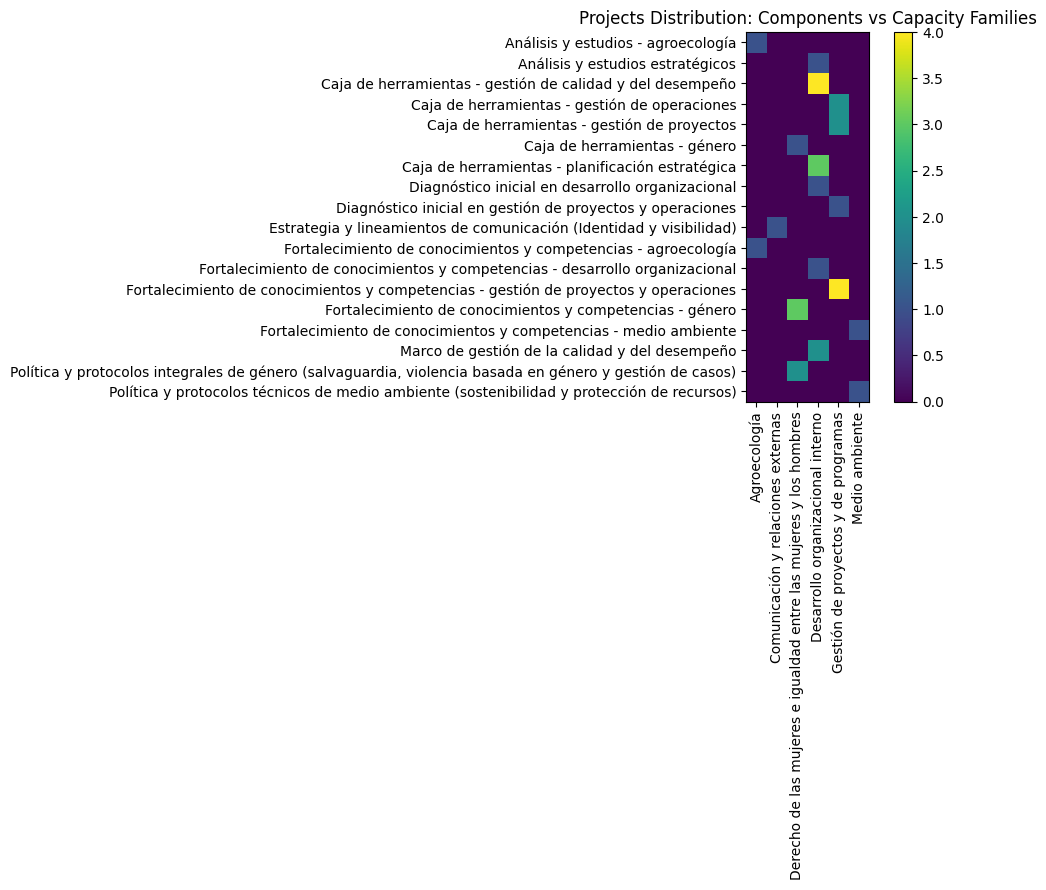

In [3]:
import matplotlib.pyplot as plt

df.columns = df.columns.str.lower()

pivot = df.pivot_table(
    index="titulo_componente",
    columns="familia_capacidades",
    values="id_proyecto",
    aggfunc="nunique",
    fill_value=0
)

plt.figure()
plt.imshow(pivot)
plt.title("Projects Distribution: Components vs Capacity Families")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar()
plt.show()

The matrix reflects the structural organization of intervention formats within the PCV program rather than a hierarchy of strategic priorities. Capacity families should be interpreted as functional groupings of activities rather than indicators of importance.

Organizational development and project management appear more prominent due to their role as transversal, standardized intervention streams (tools, training, and management frameworks). In contrast, areas such as agroecology, environment, communication, and women’s rights and gender equality are more specialized and targeted, reflecting focused thematic interventions rather than cross-cutting support functions.

Overall, the structure highlights a dual program logic: transversal capacity-building systems that support implementation across all domains, and thematic intervention areas oriented toward specific development outcomes.

## 3.3-Program Structural Composition

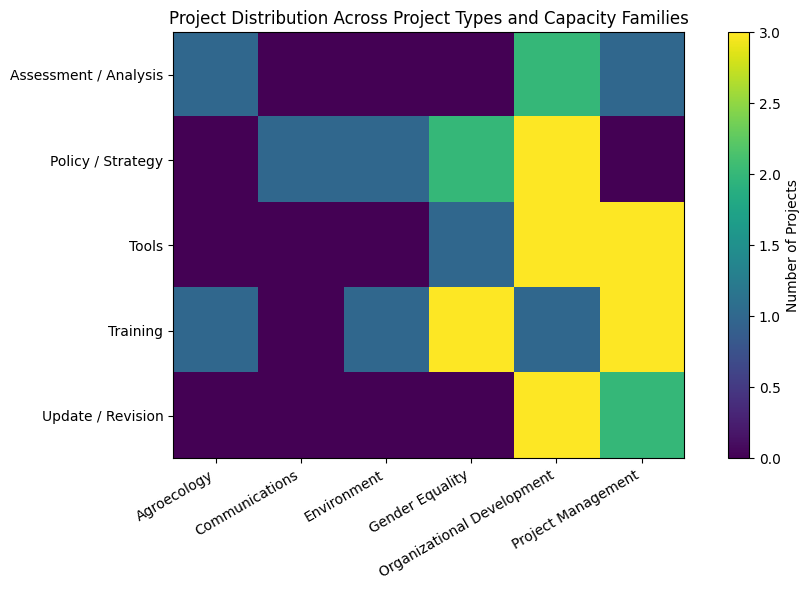

In [4]:
# Standardized project type taxonomy

tipo_mapping = {
    "Plan, estrategía o política": "Policy / Strategy",
    "Herramientas": "Tools",
    "Capacitación y transferencia de conocimientos": "Training",
    "Análisis, estudio, diagnóstico o informe": "Assessment / Analysis",
    "Actualización o revisión": "Update / Revision"
}

df["tipo_clean"] = df["tipo_proyecto"].map(tipo_mapping)

# Standardized capacity family taxonomy

cap_mapping = {
    "Derecho de las mujeres e igualdad entre las mujeres y los hombres": "Gender Equality",
    "Agroecología": "Agroecology",
    "Medio ambiente": "Environment",
    "Emprendimiento y economía solidaria": "Solidarity Economy",
    "Comunicación y relaciones externas": "Communications",
    "Gestión de proyectos y de programas": "Project Management",
    "Desarrollo organizacional interno": "Organizational Development"
}

df["cap_clean"] = df["familia_capacidades"].map(cap_mapping)

# Heatmap table

h = df.pivot_table(
    index="tipo_clean",
    columns="cap_clean",
    values="id_proyecto",
    aggfunc="nunique",
    fill_value=0
)

# Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(h)

plt.xticks(
    range(len(h.columns)),
    h.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(h.index)),
    h.index
)

plt.title("Project Distribution Across Project Types and Capacity Families")

plt.colorbar(label="Number of Projects")

plt.tight_layout()
plt.show()

The heatmap highlights a differentiated intervention structure across capacity families. Organizational Development and Project Management combine the widest variety of intervention formats, while thematic areas such as Agroecology, Environment, and Communications rely on more specialized project structures. No projects were identified within the economic dimension, suggesting limited intervention coverage.

## 3.4-Project Typology and Strategic Orientation

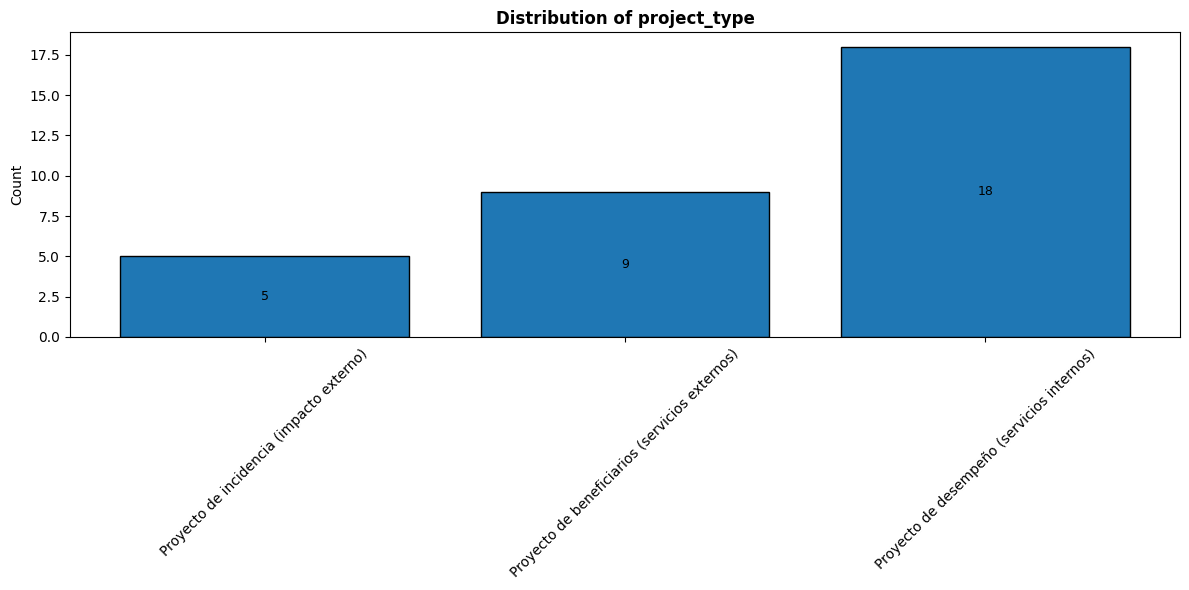

In [5]:
# Number of projects by project type
project_dist = df.groupby("project_type")["id_proyecto"].nunique()

# Plot
from visualization.explore_discrete import plot_discrete_distribution
plot_discrete_distribution(df, ["project_type"],figsize=(12,6))

The project portfolio is dominated by internally oriented performance projects, which represent more than half of all interventions. External beneficiary-focused projects account for roughly one quarter of the portfolio, while incidence-oriented projects remain comparatively limited. Finally, no projects are captured under the economic external impact dimension.

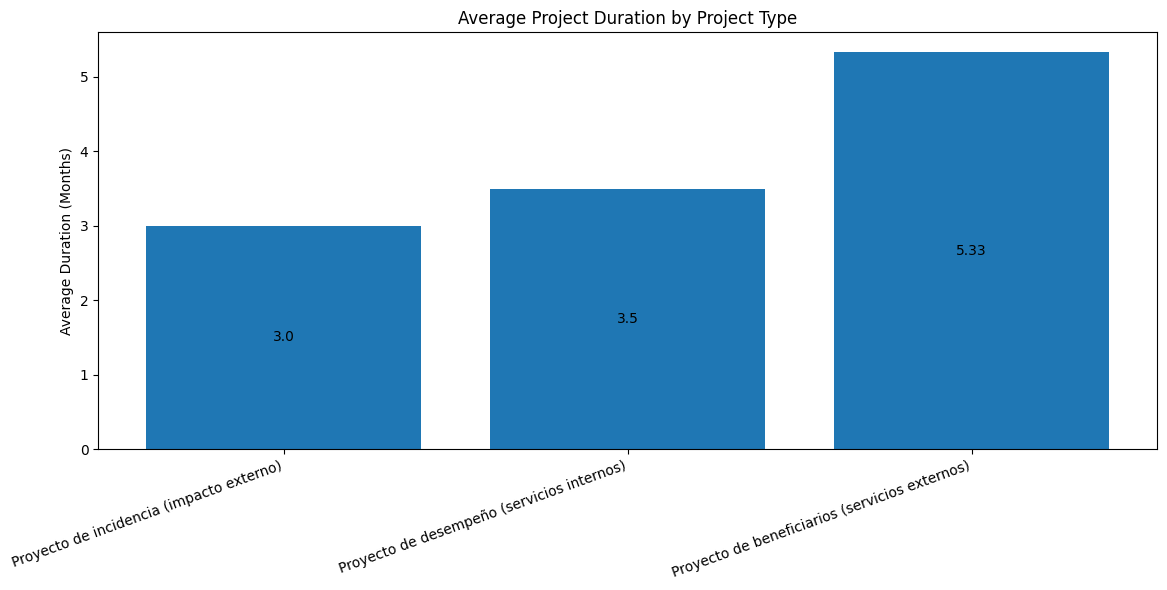

In [6]:
# Average duration by project type
duration_by_type = (
    df.groupby("project_type")["duración estimada en meses"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    duration_by_type.index,
    duration_by_type.values
)

# Data labels centered in bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        round(bar.get_height(), 2),
        ha='center',
        va='center',
        fontsize=10,
        color='black'
    )

plt.title("Average Project Duration by Project Type")
plt.ylabel("Average Duration (Months)")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

External beneficiary-oriented projects are the longest interventions on average, requiring over five months of implementation, which reflects their higher coordination and field engagement requirements. Internal performance projects sit in the middle range, while incidence-oriented projects are the shortest, suggesting more targeted and focused intervention logics with lower operational duration.

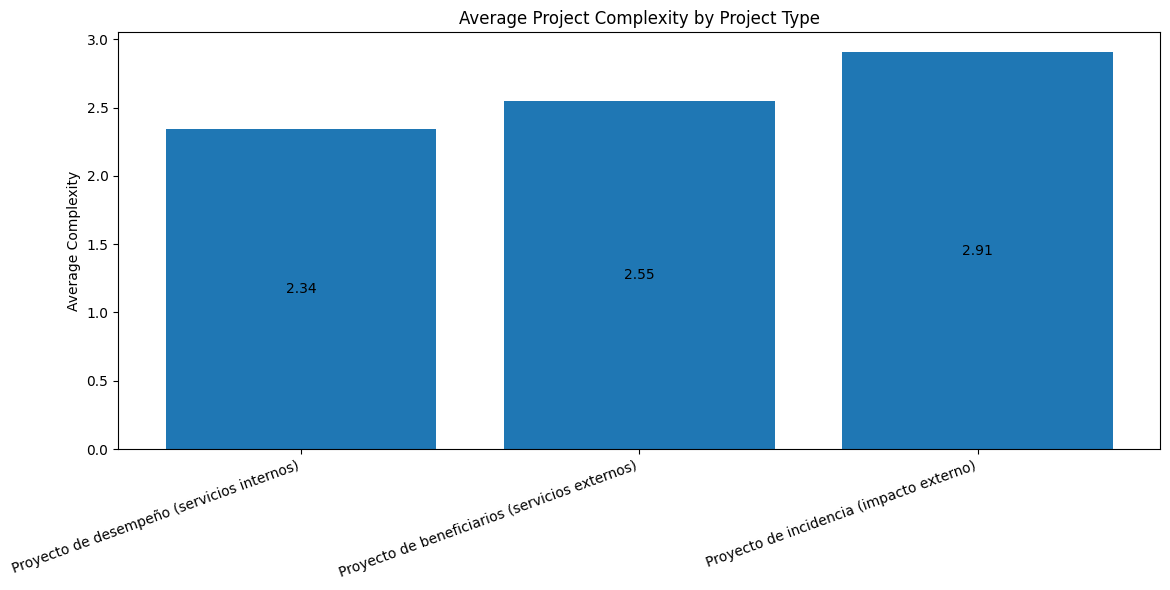

In [7]:
# Average complexity by project type
complexity_by_type = (
    df.groupby("project_type")["complejidad_promedio"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    complexity_by_type.index,
    complexity_by_type.values
)

# Data labels centered in bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        round(bar.get_height(), 2),
        ha='center',
        va='center',
        fontsize=10,
        color='black'
    )

plt.title("Average Project Complexity by Project Type")
plt.ylabel("Average Complexity")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

Complexity increases clearly along the external orientation of projects. Internal performance projects are the least complex, reflecting more standardized and controlled operational environments. Beneficiary-focused projects show moderate complexity, while incidence-oriented projects are the most complex, suggesting higher strategic ambiguity, multi-actor coordination, and broader systemic impact requirements.

## 3.5-Strategic Complexity Profile

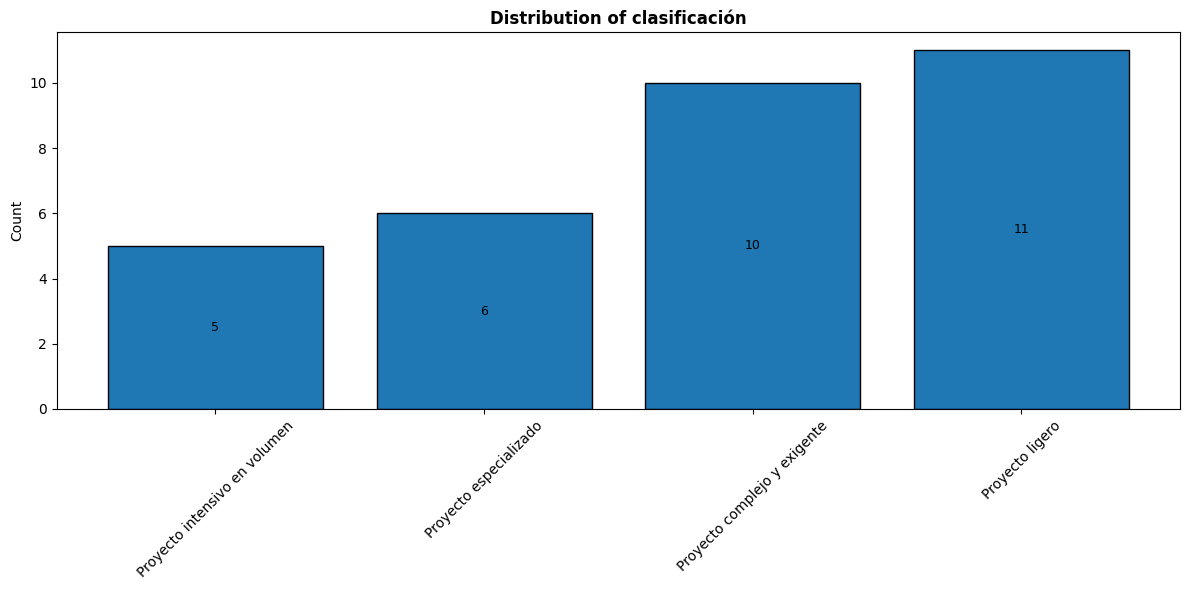

In [8]:
# Number of projects by strategic classification
clas_dist = df.groupby("clasificación")["id_proyecto"].nunique()

# Plot
from visualization.explore_discrete import plot_discrete_distribution
plot_discrete_distribution(df, ["clasificación"],figsize=(12,6))

The strategic classification structure is relatively balanced across operational intensity profiles. Lightweight and complex projects together account for nearly two thirds of the portfolio, while specialized and volume-intensive projects remain less frequent. This indicates a combination of flexible interventions and operationally demanding implementation processes within the program.

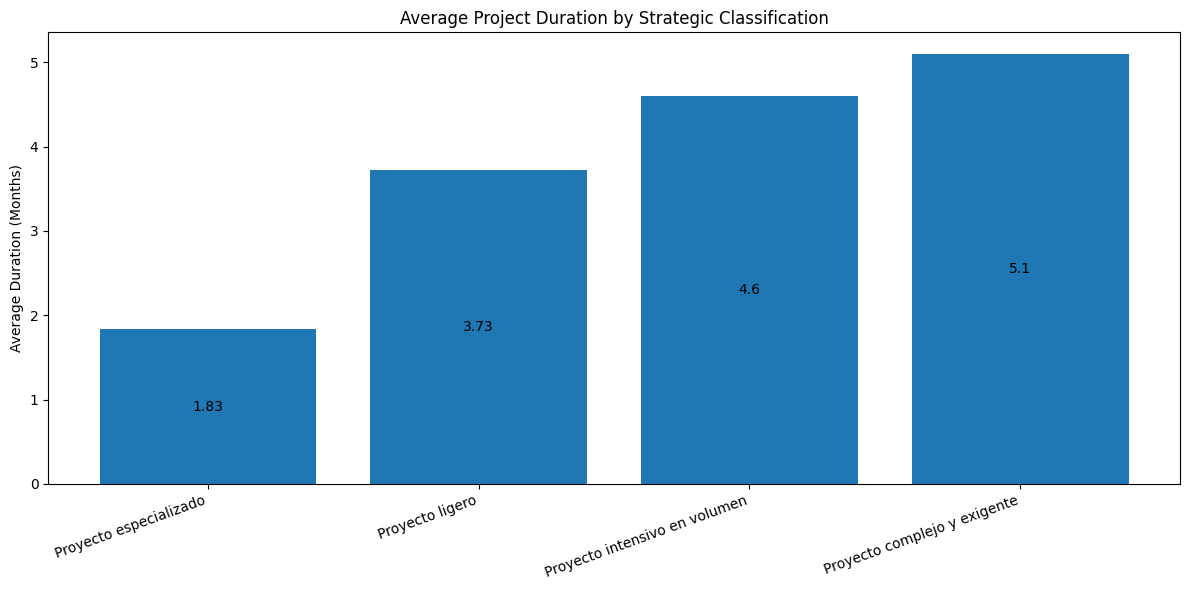

In [9]:
duration_by_class = (
    df.groupby("clasificación")["duración estimada en meses"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    duration_by_class.index,
    duration_by_class.values
)

# Data labels centered in bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        round(bar.get_height(), 2),
        ha='center',
        va='center',
        fontsize=10,
        color='black'
    )

plt.title("Average Project Duration by Strategic Classification")
plt.ylabel("Average Duration (Months)")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

The duration profile reveals a clear operational gradient across strategic classifications. Specialized projects are the shortest interventions, averaging less than two months, while lightweight and volume-intensive projects require progressively longer implementation periods. Complex and demanding projects represent the longest operational commitments, exceeding five months on average, reflecting their broader scope, coordination requirements, and implementation intensity.

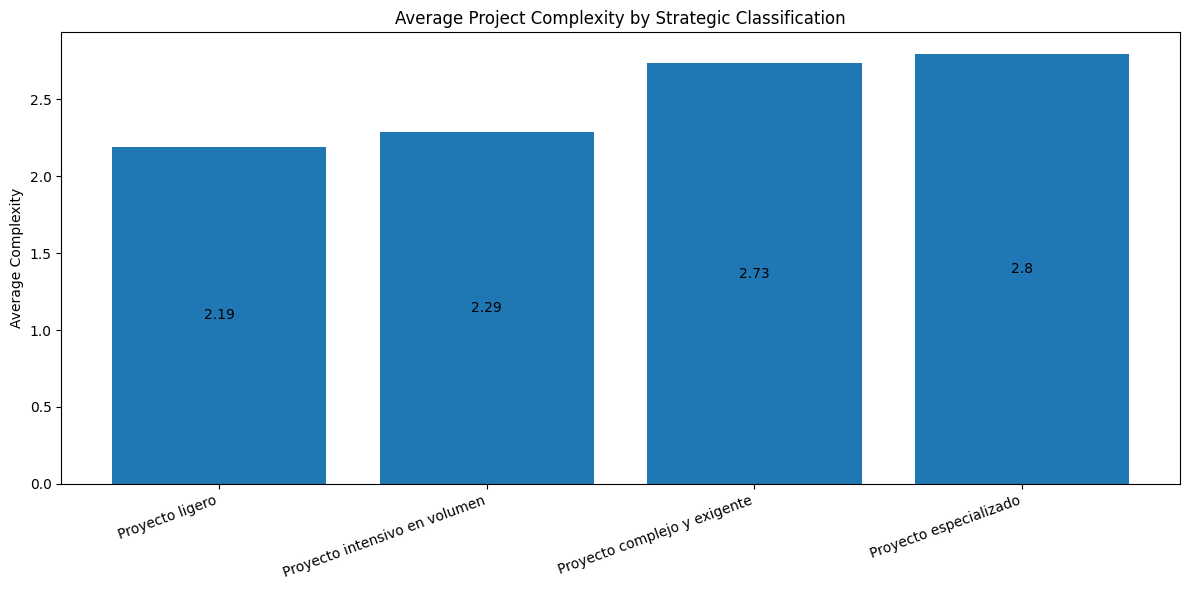

In [10]:
# Average complexity by strategic classification
complexity_by_class = (
    df.groupby("clasificación")["complejidad_promedio"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    complexity_by_class.index,
    complexity_by_class.values
)

# Data labels centered in bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        round(bar.get_height(), 2),
        ha='center',
        va='center',
        fontsize=10,
        color='black'
    )

plt.title("Average Project Complexity by Strategic Classification")
plt.ylabel("Average Complexity")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

The complexity structure differs slightly from the duration profile. Specialized projects present the highest average complexity despite being the shortest interventions, suggesting highly technical or targeted implementation requirements. Complex and demanding projects also maintain elevated complexity levels, while lightweight and volume-intensive projects remain comparatively less complex operationally. Overall, project duration and project complexity do not evolve perfectly together, indicating distinct organizational dynamics between operational intensity and technical sophistication.

## 3.6-Mandate & Operational Concentration

In [11]:
# Projects per mandate (via deliverables table)
projects_per_mandate = df_entregables.groupby("id_mandato")["id_proyecto"].nunique().reset_index()
projects_per_mandate.columns = ["id_mandato", "nb_projects"]

# Deliverables per mandate
deliverables_per_mandate = df_entregables.groupby("id_mandato")["id_entregable"].count().reset_index()
deliverables_per_mandate.columns = ["id_mandato", "nb_deliverables"]

# Build final mandate table
mandate_table = df_mandatos[[
    "id_mandato",
    "titulo_mandato"
]].merge(projects_per_mandate, on="id_mandato", how="left") \
  .merge(deliverables_per_mandate, on="id_mandato", how="left")

# Sort mandates by workload
mandate_rank = mandate_table.sort_values("nb_deliverables", ascending=False)

mandate_rank

,id_mandato,titulo_mandato,nb_projects,nb_deliverables
7,8,Mandato de SEA,12,38
8,9,Mandato de gestión de proyectos,9,28
5,6,Mandato de IMH,3,13
6,7,Mandato de IMH,4,11
2,3,Mandato de comunicación,2,8
4,5,Mandato de medio ambiente,3,7
1,2,Mandato de SEA,1,5
3,4,Mandato de medio ambiente,1,5
0,1,Mandato de SEA,1,4
9,10,Mandato de agroecología,1,4


The operational structure shows a strong concentration of activity within a limited number of mandates. Mandato de SEA and Mandato de gestión de proyectos clearly act as the main operational hubs, combining both high project counts and deliverable volumes. Mid-level mandates such as IMH and communication play a secondary but still significant role, while several mandates (agroecology, representation, and parts of SEA and environment) remain low-intensity contributors with minimal project and deliverable loads. Overall, the program is structurally uneven, with a small number of mandates absorbing most of the operational execution capacity.

## 3.7-Partner Execution Structure

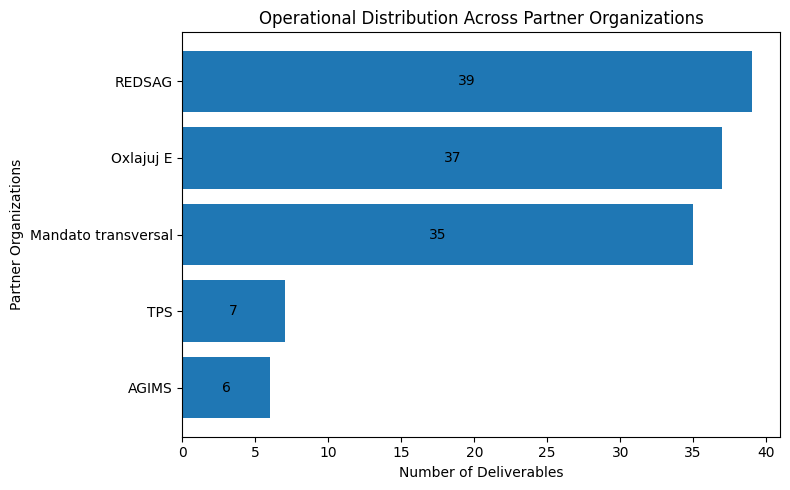

In [12]:
# Partner table
partner_table = df_entregables.groupby("id_socio").agg(
    nb_deliverables=("id_entregable", "count"),
    nb_projects=("id_proyecto", "nunique")
).reset_index()

partner_table = partner_table.merge(
    df_socios[["id_socio", "nombre_organizacion"]],
    on="id_socio",
    how="left"
)

partner_table = partner_table.sort_values("nb_deliverables", ascending=True)

plt.figure(figsize=(8,5))

bars = plt.barh(
    partner_table["nombre_organizacion"],
    partner_table["nb_deliverables"]
)

for bar in bars:
    plt.text(
        bar.get_width()/2,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        ha='center',
        va='center',
        fontsize=10,
        color='black'
    )

plt.title("Operational Distribution Across Partner Organizations")
plt.xlabel("Number of Deliverables")
plt.ylabel("Partner Organizations")

plt.tight_layout()
plt.show()

The distribution of deliverables across partner organizations reveals a pronounced concentration of operational responsibility. A limited number of partners account for a disproportionately large share of program delivery, while others maintain relatively low levels of operational engagement. 

This pattern should be interpreted in light of staggered partnership activation over the 5-year period, as some partnerships were established more recently and have therefore had less time to accumulate deliverables. 

Overall, this suggests a structurally uneven implementation model in which program execution is concentrated in a small set of key organizational actors, while distribution across the partnership network is also shaped by temporal entry effects rather than purely structural imbalance.

## 3.8-Composite Program Index Framework

As defined in the second notebook, a set of composite indicators was constructed to capture distinct dimensions of project implementation and organizational change. This section operationalizes these indices for interpretative analysis across the reconstructed program dataset.

Level | Composite Index | Core Analytical Dimension | Construction Logic | Analytical Objective
---|---|---|---|---
Deliverable | Complexity Index | Operational intensity | Combines effort, workload, and production volume | Captures the level of coordination, resource use, and operational effort required to produce deliverables
Project | Quality Index | Intrinsic technical adequacy | Evaluation of structural completeness, methodological rigor, and internal coherence of deliverables | Isolates the intrinsic structural and technical quality of project outputs independently from outcomes or utilization
Project | Adoption Index | Organizational appropriation | Combines relevance, satisfaction, sustainability, and usage | Measures partner acceptance, alignment with needs, and degree of institutional uptake
Project | Transformation Index | Organizational change | Combines internal change and organizational scope | Captures structural and institutional changes induced within partner organizations
Project | Outcomes Index | Observable project effects | Aggregates performance, beneficiaries, economic effects, and influence dimensions | Measures multidimensional effects generated by the intervention at outcome level
Project | Context Index | Organizational absorption capacity | Combines maturity and collaboration conditions | Represents structural and relational conditions that enable or constrain implementation
Project | Risk Index | Operational and contextual uncertainty | Combines internal stability and external volatility | Captures exposure to internal instability and external environmental uncertainty

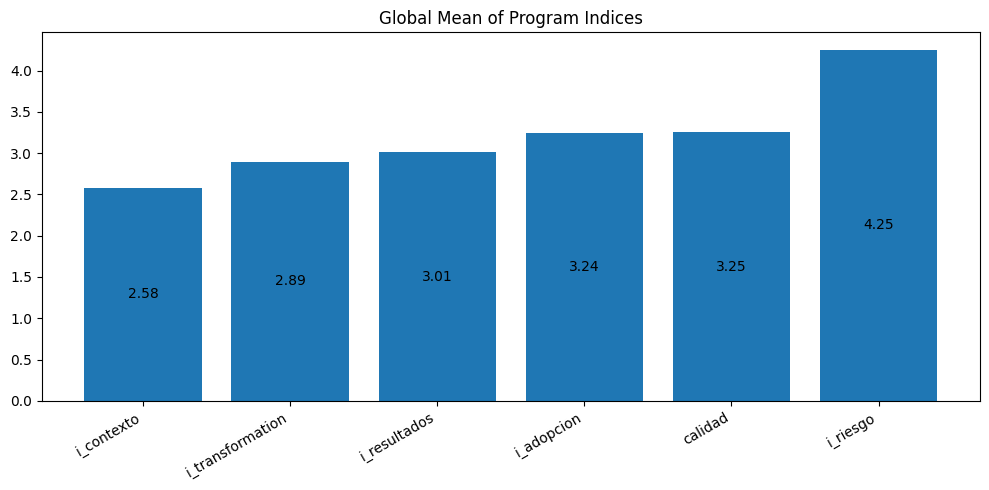

In [13]:
indices_global = df[[
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]].mean().sort_values()

plt.figure(figsize=(10,5))

bars = plt.bar(indices_global.index, indices_global.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        round(bar.get_height(), 2),
        ha='center',
        va='center',
        fontsize=10,
        color='black'
    )

plt.title("Global Mean of Program Indices")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The global index profile provides a descriptive overview of the 32-project portfolio rather than inferential evidence. Quality, adoption, and risk (inverted, where higher values indicate lower risk) are relatively strong across the program, suggesting generally solid implementation conditions. In contrast, context and transformation are the lowest dimensions, pointing to more limited organizational absorption capacity and weaker structural change dynamics at the portfolio level.

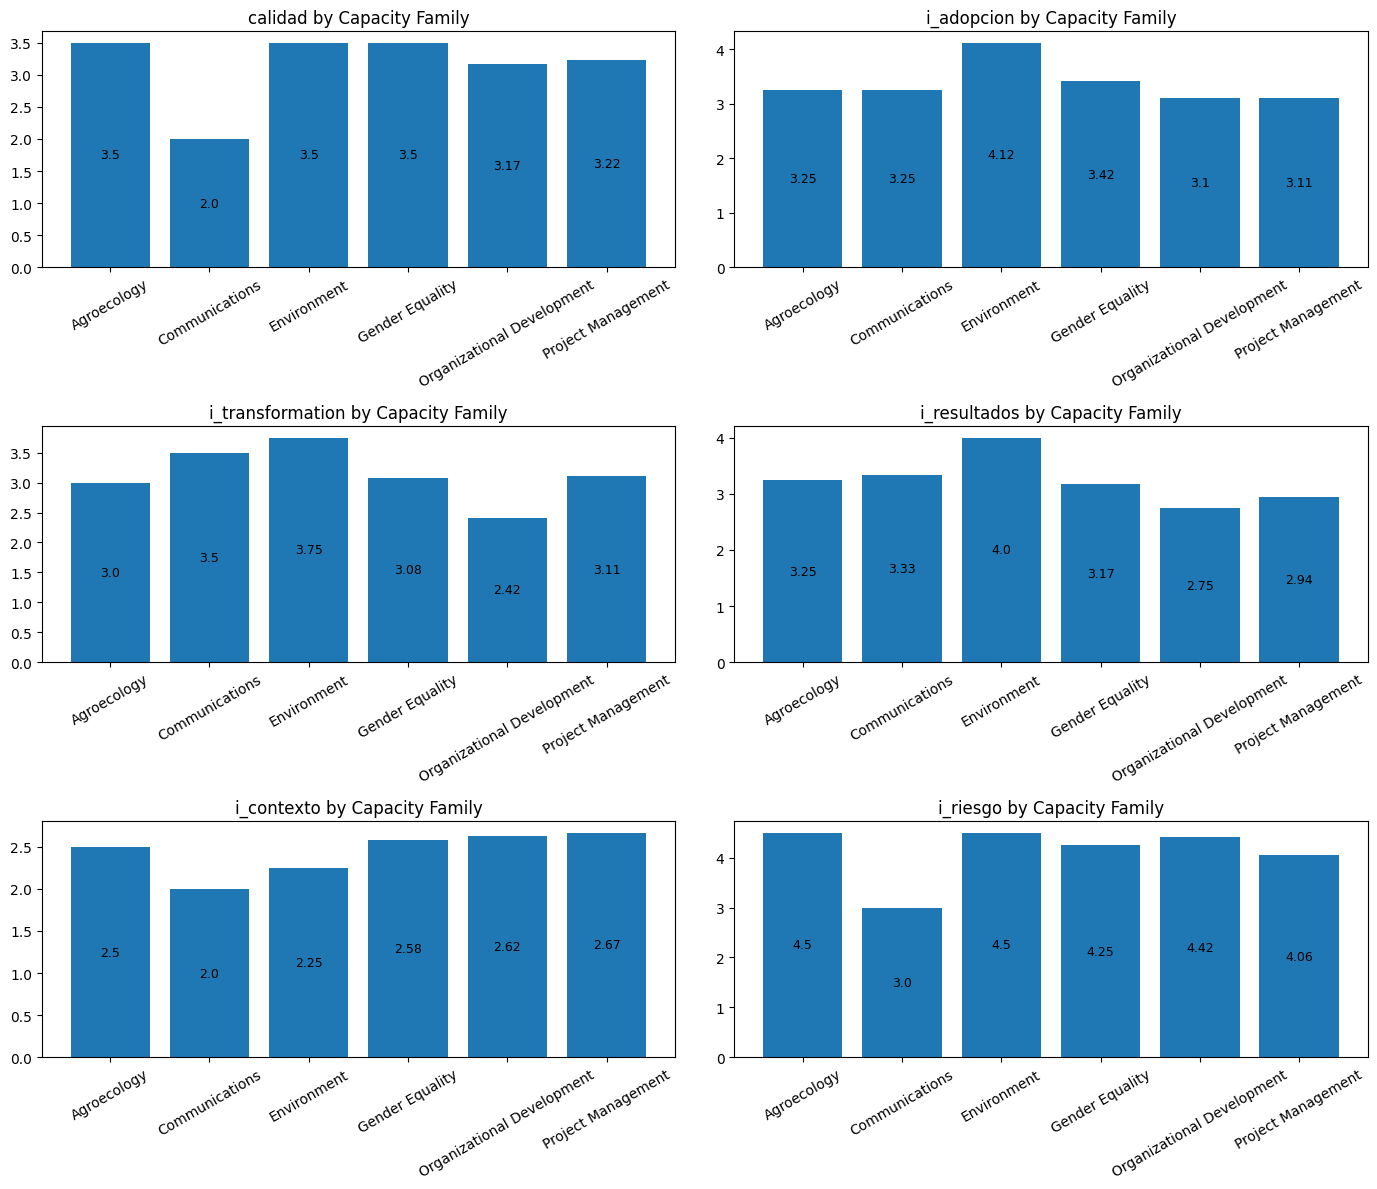

In [14]:
import math

indices_cap = df.groupby("cap_clean")[[
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]].mean()

cols = indices_cap.columns
n = len(cols)

ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    bars = ax.bar(indices_cap.index, indices_cap[col])
    
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            round(bar.get_height(), 2),
            ha='center',
            va='center',
            fontsize=9,
            color='black'
        )
    
    ax.set_title(f"{col} by Capacity Family")
    ax.tick_params(axis='x', rotation=30)

# Remove empty plots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Across capacity families, the indices show a structured but heterogeneous performance profile. Environmental and Gender Equality interventions tend to display higher levels of adoption and results, suggesting stronger alignment and perceived effectiveness within these thematic areas. Organizational Development and Project Management show comparatively lower transformation and results scores, reflecting their more infrastructural or enabling nature rather than direct outcome generation.

Context scores remain relatively low across all families, indicating that organizational absorption conditions are a consistent constraint regardless of thematic domain. Finally, risk scores are systematically high across categories (and inverted in interpretation), suggesting generally stable implementation conditions, with only moderate variation between capacity families.

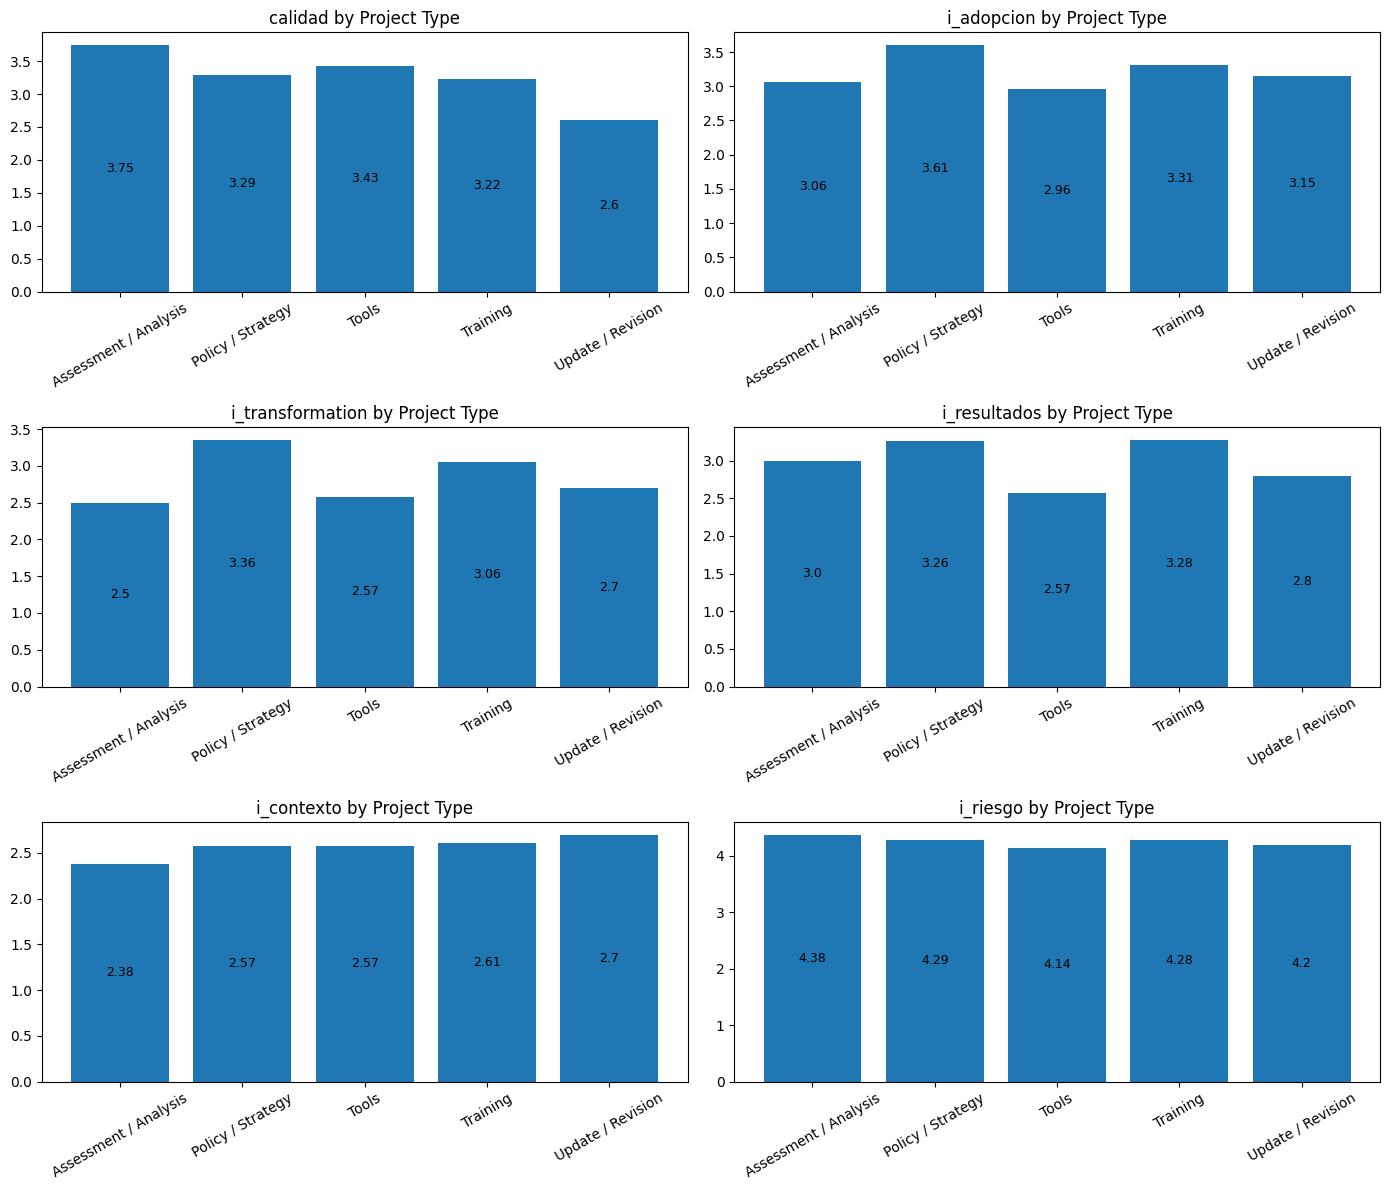

In [15]:
indices_tipo = df.groupby("tipo_clean")[[
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]].mean()

cols = indices_tipo.columns
n = len(cols)

ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    bars = ax.bar(indices_tipo.index, indices_tipo[col])
    
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            round(bar.get_height(), 2),
            ha='center',
            va='center',
            fontsize=9,
            color='black'
        )
    
    ax.set_title(f"{col} by Project Type")
    ax.tick_params(axis='x', rotation=30)

# Remove empty axes if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Across project types, the index profiles remain relatively coherent, with differences that are more gradual than structural given the limited size of the portfolio (32 projects). Assessment/Analysis projects show the highest technical quality, while Policy/Strategy and Training types display more balanced profiles across adoption, transformation, and results, suggesting more integrated implementation dynamics.

Tools and Update/Revision projects tend to score lower on transformation and results, which is consistent with their more operational or incremental nature. Context scores remain relatively stable across all types and generally low, indicating a shared constraint in organizational absorption conditions. Risk (inverted) remains consistently high across categories, pointing to broadly stable implementation environments with limited variation between project types.

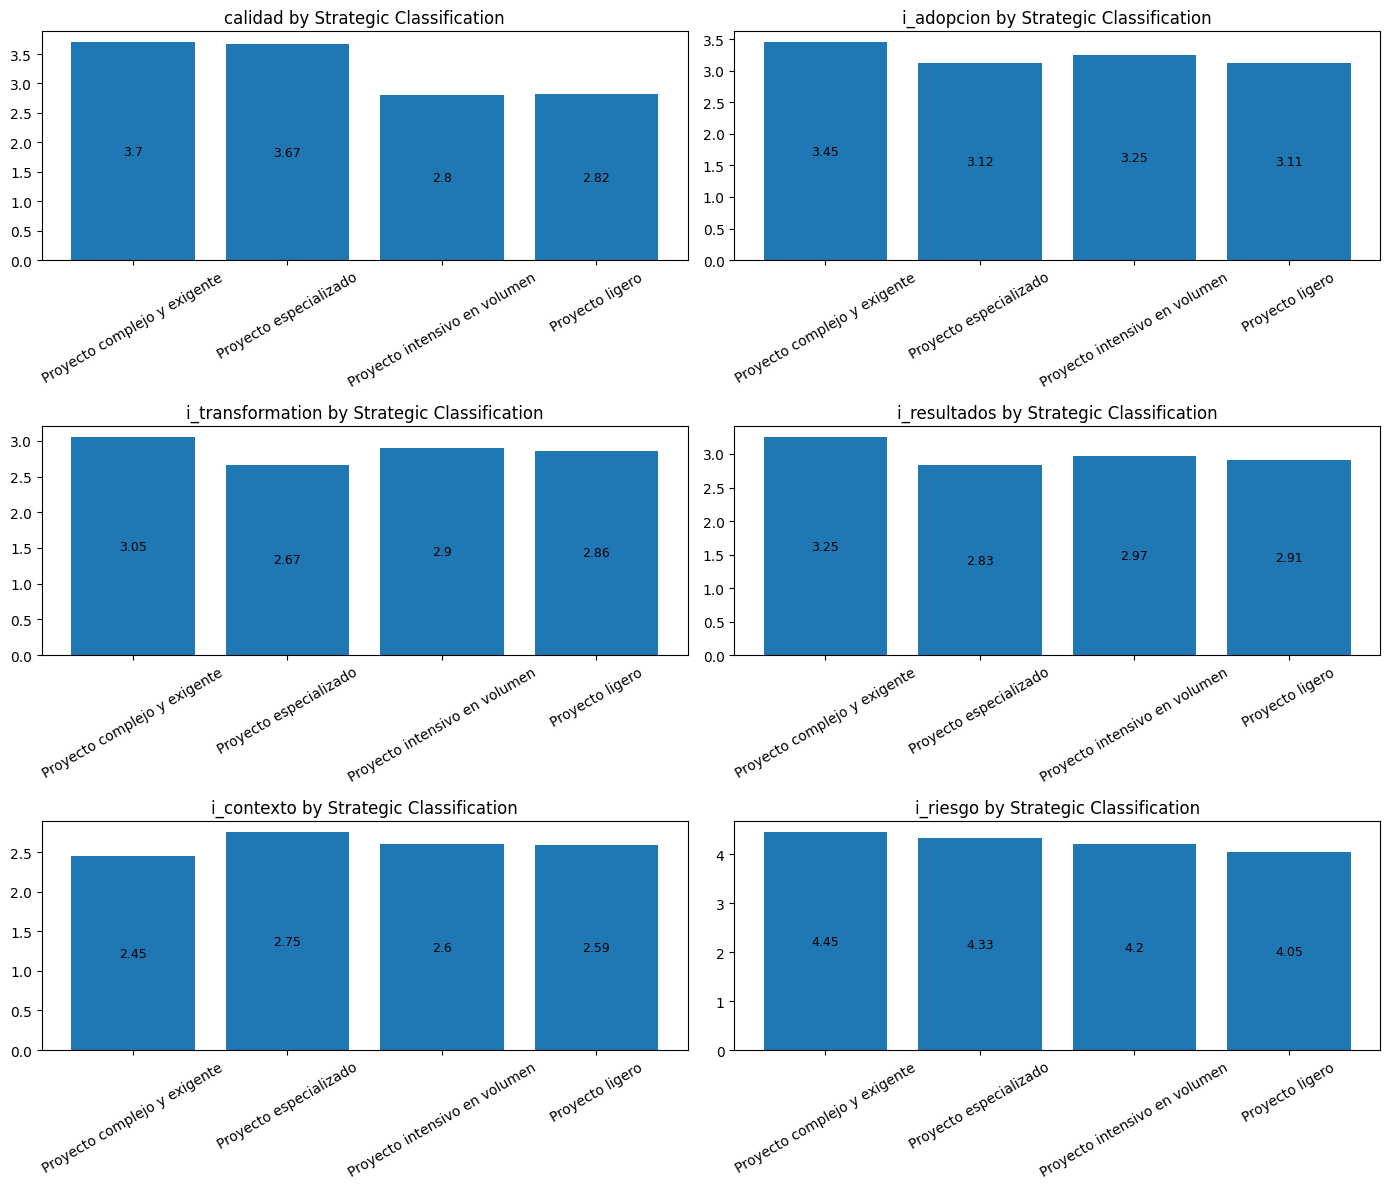

In [16]:
indices_class = df.groupby("clasificación")[[
    "calidad",
    "i_adopcion",
    "i_transformation",
    "i_resultados",
    "i_contexto",
    "i_riesgo"
]].mean()

cols = indices_class.columns
n = len(cols)

ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    bars = ax.bar(indices_class.index, indices_class[col])
    
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            round(bar.get_height(), 2),
            ha='center',
            va='center',
            fontsize=9,
            color='black'
        )
    
    ax.set_title(f"{col} by Strategic Classification")
    ax.tick_params(axis='x', rotation=30)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Across strategic classifications, the index profiles show relatively modest variation, suggesting that differences are more related to operational intensity than fundamentally distinct performance regimes within the 32-project portfolio.

“Proyecto complejo y exigente” tends to exhibit higher levels of quality, adoption, and results, which is consistent with its more resource-intensive and coordinated nature. “Proyecto especializado” shows relatively high quality but lower transformation and results, suggesting technically strong but more contained interventions. In contrast, “Proyecto ligero” and “Proyecto intensivo en volumen” display more moderate profiles across most dimensions, with no clear dominance on outcomes or transformation.

Context remains consistently low across all classifications, reinforcing the idea that organizational absorption capacity is a systemic constraint rather than a project-type-specific effect. Risk (inverted) remains uniformly high, indicating broadly stable implementation conditions across all strategic categories, with limited differentiation in exposure to uncertainty.

## 3.9-Summary - Key Insights

| Section                | Process                      | Key Insight                                                              | Analytical Implication                                              |
| ---------------------- | ---------------------------- | ------------------------------------------------------------------------ | ------------------------------------------------------------------- |
| Program Scale          | Portfolio overview           | 32 projects, 124 deliverables, concentrated operational system           | Small but dense program → suitable for descriptive + ML exploration |
| Structural Logic       | Component × capacity mapping | Clear split between transversal (management, org dev) and thematic areas | Program operates as a dual system: support vs thematic delivery     |
| Project Typology       | Intervention classification  | Internal performance projects dominate portfolio                         | Program is more internal execution-focused than impact-oriented     |
| Operational Intensity  | Complexity & duration        | External/beneficiary projects are longer and more complex                | Operational load increases with external engagement                 |
| Mandate Structure      | Workload distribution        | Strong concentration in SEA and Project Management mandates              | Execution is centralized → potential structural bottleneck          |
| Partner Structure      | Deliverable distribution     | Few partners handle most implementation                                  | High dependency on limited execution actors                         |
| Composite Indices      | Multidimensional profiling   | Risk high (stable), context low, transformation moderate                 | Program is stable but structurally limited in change capacity       |
| Index Relationships    | Correlation patterns         | Adoption–transformation–results are linked                               | Performance dimensions behave as a coherent system                  |
| Capacity Differences   | Functional variation         | Environment and Gender Equality show strongest results                   | Thematic areas drive outcomes more than support functions           |
| Project Types          | Intervention logic           | Training/Policy more balanced; Tools/Updates weaker                      | Format of intervention strongly influences performance              |
| Classification Effects | Operational intensity | Complexity is associated with quality, but does not systematically translate into improved outcomes | The relationship between operational effort and results is non-linear and mediated by contextual and organizational factors
| System Constraint      | Context dimension            | Context consistently low across all groups                               | Organizational absorption capacity is a systemic bottleneck         |
